# Clustering Christenson Transcription

In [1]:
import pandas as pd
import numpy as np
import plotly_express as px

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Get Data

In [43]:
DOC = pd.read_csv("christenson-quiche-PARA.csv").set_index("para_num")

In [44]:
DOC

,doc_str,n_chars
para_num,,
0,ARE V XE OHER,13
1,Tzih varal Quiche vbi.,22
2,Varal xchicatzibah vi xchicatiquiba vi oher tz...,1215
3,"ARE V TZIHOXIC VAE Cacatzinin oc, caca chamam ...",110
4,Vae cute nabe tzih nabe vchan. mahabi oε hun v...,731
...,...,...
104,unim ha. Hacavitz cut vcah ahau hun,35
105,vnim ha chi cahibcut nimha,26
106,chuvach ahau quiche,19


In [46]:
# DOC['g1'] = (DOC.index / 10).astype(int)
denom = 10
DOC['g1'] = DOC.index // denom
DOC['g2'] = DOC.index % denom
DOC = DOC.reset_index().set_index(['g1','g2','para_num'])

In [47]:
DOC

doc_str  n_chars
g1 g2 para_num                                                            
0  0  0                                             ARE V XE OHER       13
   1  1                                    Tzih varal Quiche vbi.       22
   2  2         Varal xchicatzibah vi xchicatiquiba vi oher tz...     1215
   3  3         ARE V TZIHOXIC VAE Cacatzinin oc, caca chamam ...      110
   4  4         Vae cute nabe tzih nabe vchan. mahabi oε hun v...      731
...                                                           ...      ...
10 4  104                     unim ha. Hacavitz cut vcah ahau hun       35
   5  105                              vnim ha chi cahibcut nimha       26
   6  106                                     chuvach ahau quiche       19
   7  107       Are curi e oxib chinim chocoh queheri e cahaui...      201
   8  108       Nim chocoh cut chuvach nihaib vcab curi. nim c...      291

[109 rows x 2 columns]

# Vectorize

In [48]:
count_engine = CountVectorizer(
    ngram_range = (1,3),
    max_features = 5000)

In [49]:
X = count_engine.fit_transform(DOC.doc_str)

In [50]:
DTM = pd.DataFrame(X.toarray(), 
    columns=count_engine.get_feature_names_out(), 
    index=DOC.index)

In [51]:
DTM

abah  abah queheri  abah ri  abah ta  abi  abix  abixic  acab  \
g1 g2 para_num                                                                  
0  0  0            0             0        0        0    0     0       0     0   
   1  1            0             0        0        0    0     0       0     0   
   2  2            0             0        0        0    0     0       0     0   
   3  3            0             0        0        0    0     0       0     0   
   4  4            1             0        0        0    0     0       0     0   
...              ...           ...      ...      ...  ...   ...     ...   ...   
10 4  104          0             0        0        0    0     0       0     0   
   5  105          0             0        0        0    0     0       0     0   
   6  106          0             0        0        0    0     0       0     0   
   7  107          0             0        0        0    0     0       0     0   
   8  108          0             0        0        0    0     0       0     0   

                acab mahucutah  acab mahucutah iqui  ...  εaεal qui  εaεal ri  \
g1 g2 para_num                                       ...                        
0  0  0                      0                    0  ...          0         0   
   1  1                      0                    0  ...          0         0   
   2  2                      0                    0  ...          0         0   
   3  3                      0                    0  ...          0         0   
   4  4                      0                    0  ...          0         0   
...                        ...                  ...  ...        ...       ...   
10 4  104                    0                    0  ...          0         0   
   5  105                    0                    0  ...          0         0   
   6  106                    0                    0  ...          0         0   
   7  107                    0                    0  ...          0         0   
   8  108                    0                    0  ...          0         0   

                εaεal tepeval  εaεate  εaεche  εaεchequeleb  εaεchequeleb ah  \
g1 g2 para_num                                                                 
0  0  0                     0       0       0             0                0   
   1  1                     0       0       0             0                0   
   2  2                     0       0       0             0                0   
   3  3                     0       0       0             0                0   
   4  4                     0       0       0             0                0   
...                       ...     ...     ...           ...              ...   
10 4  104                   0       0       0             0                0   
   5  105                   0       0       0             0                0   
   6  106                   0       0       0             0                0   
   7  107                   0       0       0             0                0   
   8  108                   0       0       0             0                0   

                εaεchequeleb ah iquinaha  εaεchequeleb ahq  εol  
g1 g2 para_num                                                   
0  0  0                                0                 0    0  
   1  1                                0                 0    0  
   2  2                                0                 0    0  
   3  3                                0                 0    0  
   4  4                                0                 0    0  
...                                  ...               ...  ...  
10 4  104                              0                 0    0  
   5  105                              0                 0    0  
   6  106                              0                 0    0  
   7  107                              0                 0    0  
   8  108                              0                 0    0  

[109 row

# TFIDF

In [52]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True)

In [53]:
X1 = tfidf_engine.fit_transform(DTM)

In [54]:
TFIDF = pd.DataFrame(X1.toarray(), columns=DTM.columns, index=DTM.index)

In [55]:
TFIDF

abah  abah queheri  abah ri  abah ta  abi  abix  abixic  \
g1 g2 para_num                                                                
0  0  0         0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   1  1         0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   2  2         0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   3  3         0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   4  4         0.052221           0.0      0.0      0.0  0.0   0.0     0.0   
...                  ...           ...      ...      ...  ...   ...     ...   
10 4  104       0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   5  105       0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   6  106       0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   7  107       0.000000           0.0      0.0      0.0  0.0   0.0     0.0   
   8  108       0.000000           0.0      0.0      0.0  0.0   0.0     0.0   

                acab  acab mahucutah  acab mahucutah iqui  ...  εaεal qui  \
g1 g2 para_num                                             ...              
0  0  0          0.0             0.0                  0.0  ...        0.0   
   1  1          0.0             0.0                  0.0  ...        0.0   
   2  2          0.0             0.0                  0.0  ...        0.0   
   3  3          0.0             0.0                  0.0  ...        0.0   
   4  4          0.0             0.0                  0.0  ...        0.0   
...              ...             ...                  ...  ...        ...   
10 4  104        0.0             0.0                  0.0  ...        0.0   
   5  105        0.0             0.0                  0.0  ...        0.0   
   6  106        0.0             0.0                  0.0  ...        0.0   
   7  107        0.0             0.0                  0.0  ...        0.0   
   8  108        0.0             0.0                  0.0  ...        0.0   

                εaεal ri  εaεal tepeval  εaεate  εaεche  εaεchequeleb  \
g1 g2 para_num                                                          
0  0  0              0.0            0.0     0.0     0.0           0.0   
   1  1              0.0            0.0     0.0     0.0           0.0   
   2  2              0.0            0.0     0.0     0.0           0.0   
   3  3              0.0            0.0     0.0     0.0           0.0   
   4  4              0.0            0.0     0.0     0.0           0.0   
...                  ...            ...     ...     ...           ...   
10 4  104            0.0            0.0     0.0     0.0           0.0   
   5  105            0.0            0.0     0.0     0.0           0.0   
   6  106            0.0            0.0     0.0     0.0           0.0   
   7  107            0.0            0.0     0.0     0.0           0.0   
   8  108            0.0            0.0     0.0     0.0           0.0   

                εaεchequeleb ah  εaεchequeleb ah iquinaha  εaεchequeleb ahq  \
g1 g2 para_num                                                                
0  0  0                     0.0                       0.0               0.0   
   1  1                     0.0                       0.0               0.0   
   2  2                     0.0                       0.0               0.0   
   3  3                     0.0                       0.0               0.0   
   4  4                     0.0                       0.0               0.0   
...                         ...                       ...               ...   
10 4  104                   0.0                       0.0               0.0   
   5  105                   0.0                       0.0               0.0   
   6  106                   0.0                       0.0               0.0   
   7  107                   0.0                       0.0               0.0   
   8  108                   0.0                       0.0               0.0   

            

## Get VOCAB

In [56]:
VOCAB = DTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'

In [57]:
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)

In [58]:
VOCAB['df'] = DTM.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(len(DTM)/VOCAB.df)

In [59]:
# VOCAB['dp'] = VOCAB.df / VOCAB.df.sum()
VOCAB['dp'] = VOCAB.df / len(DTM)
VOCAB['di'] = np.log2(1/VOCAB.dp)
VOCAB['dh'] = VOCAB.dp * VOCAB.di

In [60]:
VOCAB['tfidf_mean'] = TFIDF.mean()

In [61]:
VOCAB['n_chars'] = VOCAB.apply(lambda x: len(x.name), 1)
VOCAB['n_tokens'] = VOCAB.apply(lambda x: len(x.name.split()), 1)

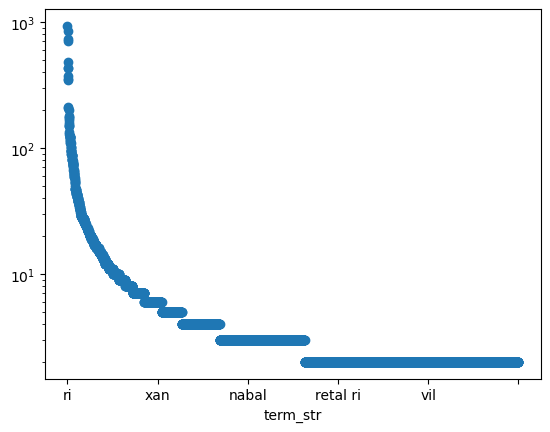

In [62]:
VOCAB.n.sort_values(ascending=False).plot(logy=True, style='o');

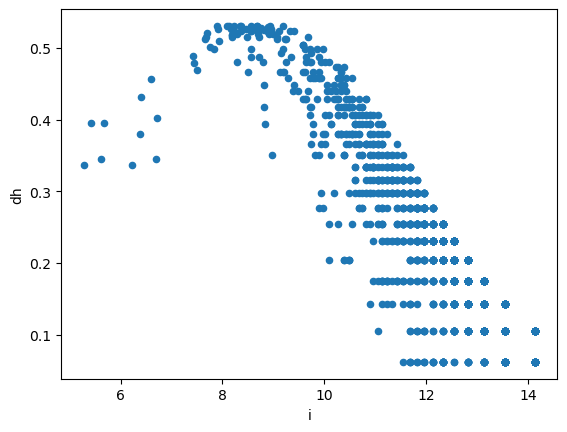

In [63]:
VOCAB.plot.scatter('i','dh');

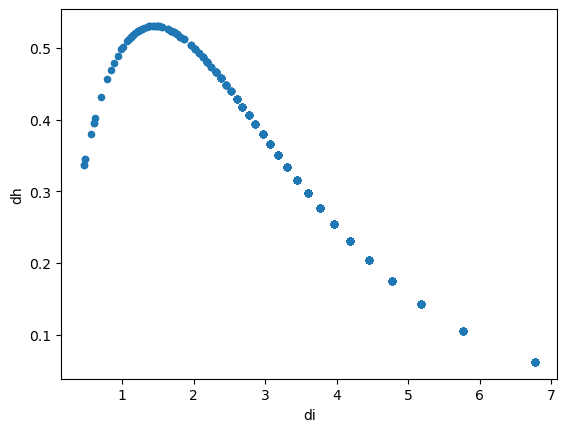

In [64]:
VOCAB.plot.scatter('di','dh');

In [65]:
VOCAB.sort_values('n', ascending=False).head(10)

,n,p,i,df,dfidf,dp,di,dh,tfidf_mean,n_chars,n_tokens
term_str,,,,,,,,,,,
ri,928,0.025743,5.279691,79,36.687883,0.724771,0.464404,0.336586,0.096628,2,1
ta,842,0.023357,5.419995,72,43.074671,0.660550,0.598259,0.395180,0.093714,2,1
cut,734,0.020361,5.618035,78,37.657004,0.715596,0.482782,0.345477,0.082253,3,1
qui,705,0.019557,5.676192,72,43.074671,0.660550,0.598259,0.395180,0.082978,3,1
chi,481,0.013343,6.227779,79,36.687883,0.724771,0.464404,0.336586,0.060978,3,1
vi,433,0.012011,6.379448,74,41.346091,0.678899,0.558731,0.379322,0.059978,2,1
xa,428,0.011873,6.396205,67,47.040374,0.614679,0.702095,0.431563,0.052798,2,1
hun,372,0.010319,6.598513,63,49.826977,0.577982,0.790904,0.457128,0.050031,3,1
are,350,0.009709,6.686461,78,37.657004,0.715596,0.482782,0.345477,0.050009,3,1


In [66]:
VOCAB.sort_index()

,n,p,i,df,dfidf,dp,di,dh,tfidf_mean,n_chars,n_tokens
term_str,,,,,,,,,,,
abah,27,0.000749,10.382784,17,45.572265,0.155963,2.680721,0.418094,0.006876,4,1
abah queheri,2,0.000055,14.137672,2,11.536369,0.018349,5.768184,0.105838,0.000931,12,2
abah ri,2,0.000055,14.137672,2,11.536369,0.018349,5.768184,0.105838,0.000606,7,2
abah ta,2,0.000055,14.137672,2,11.536369,0.018349,5.768184,0.105838,0.000701,7,2
abi,2,0.000055,14.137672,1,6.768184,0.009174,6.768184,0.062093,0.002465,3,1
...,...,...,...,...,...,...,...,...,...,...,...
εaεchequeleb,10,0.000277,11.815744,7,27.725806,0.064220,3.960829,0.254365,0.003325,12,1
εaεchequeleb ah,2,0.000055,14.137672,2,11.536369,0.018349,5.768184,0.105838,0.000532,15,2
εaεchequeleb ah iquinaha,2,0.000055,14.137672,2,11.536369,0.018349,5.768184,0.105838,0.000532,24,3


In [67]:
VOCAB.loc[(VOCAB.n_tokens >= 3) & (VOCAB.dh > .3)].sort_values('dfidf', ascending=False).head(20)

,n,p,i,df,dfidf,dp,di,dh,tfidf_mean,n_chars,n_tokens
term_str,,,,,,,,,,,
balam quitze balam,45,0.001248,9.645819,18,46.768668,0.165138,2.598259,0.429070,0.010389,18,3
hun ahpu xbalanque,43,0.001193,9.711407,16,44.290949,0.146789,2.768184,0.406339,0.010132,18,3
quitze balam acab,41,0.001137,9.780120,15,42.919406,0.137615,2.861294,0.393756,0.009704,17,3
cate cut ta,28,0.000777,10.330317,14,41.451612,0.128440,2.960829,0.380290,0.005071,11,3
mahucutah iqui balam,28,0.000777,10.330317,14,41.451612,0.128440,2.960829,0.380290,0.008078,20,3
cate puch ta,15,0.000416,11.230781,14,41.451612,0.128440,2.960829,0.380290,0.003576,12,3
ri balam quitze,22,0.000610,10.678240,13,39.880680,0.119266,3.067745,0.365878,0.005866,15,3
acab mahucutah iqui,25,0.000694,10.493815,13,39.880680,0.119266,3.067745,0.365878,0.007376,19,3
balam acab mahucutah,35,0.000971,10.008389,13,39.880680,0.119266,3.067745,0.365878,0.007727,20,3


# Get SIGS

In [68]:
SIGS = VOCAB[VOCAB.dh > VOCAB.dh.quantile(.5)].index

In [69]:
len(SIGS)

2116

# Cluster

In [ ]:
import sys
sys.path.append("../../local_lib/")

In [71]:
from hac2 import HAC

In [72]:
from sklearn.cluster import AgglomerativeClustering

In [73]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

In [74]:
# X2 = TFIDF[SIGS]

In [84]:
X2 = TFIDF

In [85]:
fig1 = HAC(X2)
fig1.linkage_method = linkage
fig1.dist_metric = metric

In [86]:
fig1.color_thresh = 1.8

<Figure size 640x480 with 0 Axes>

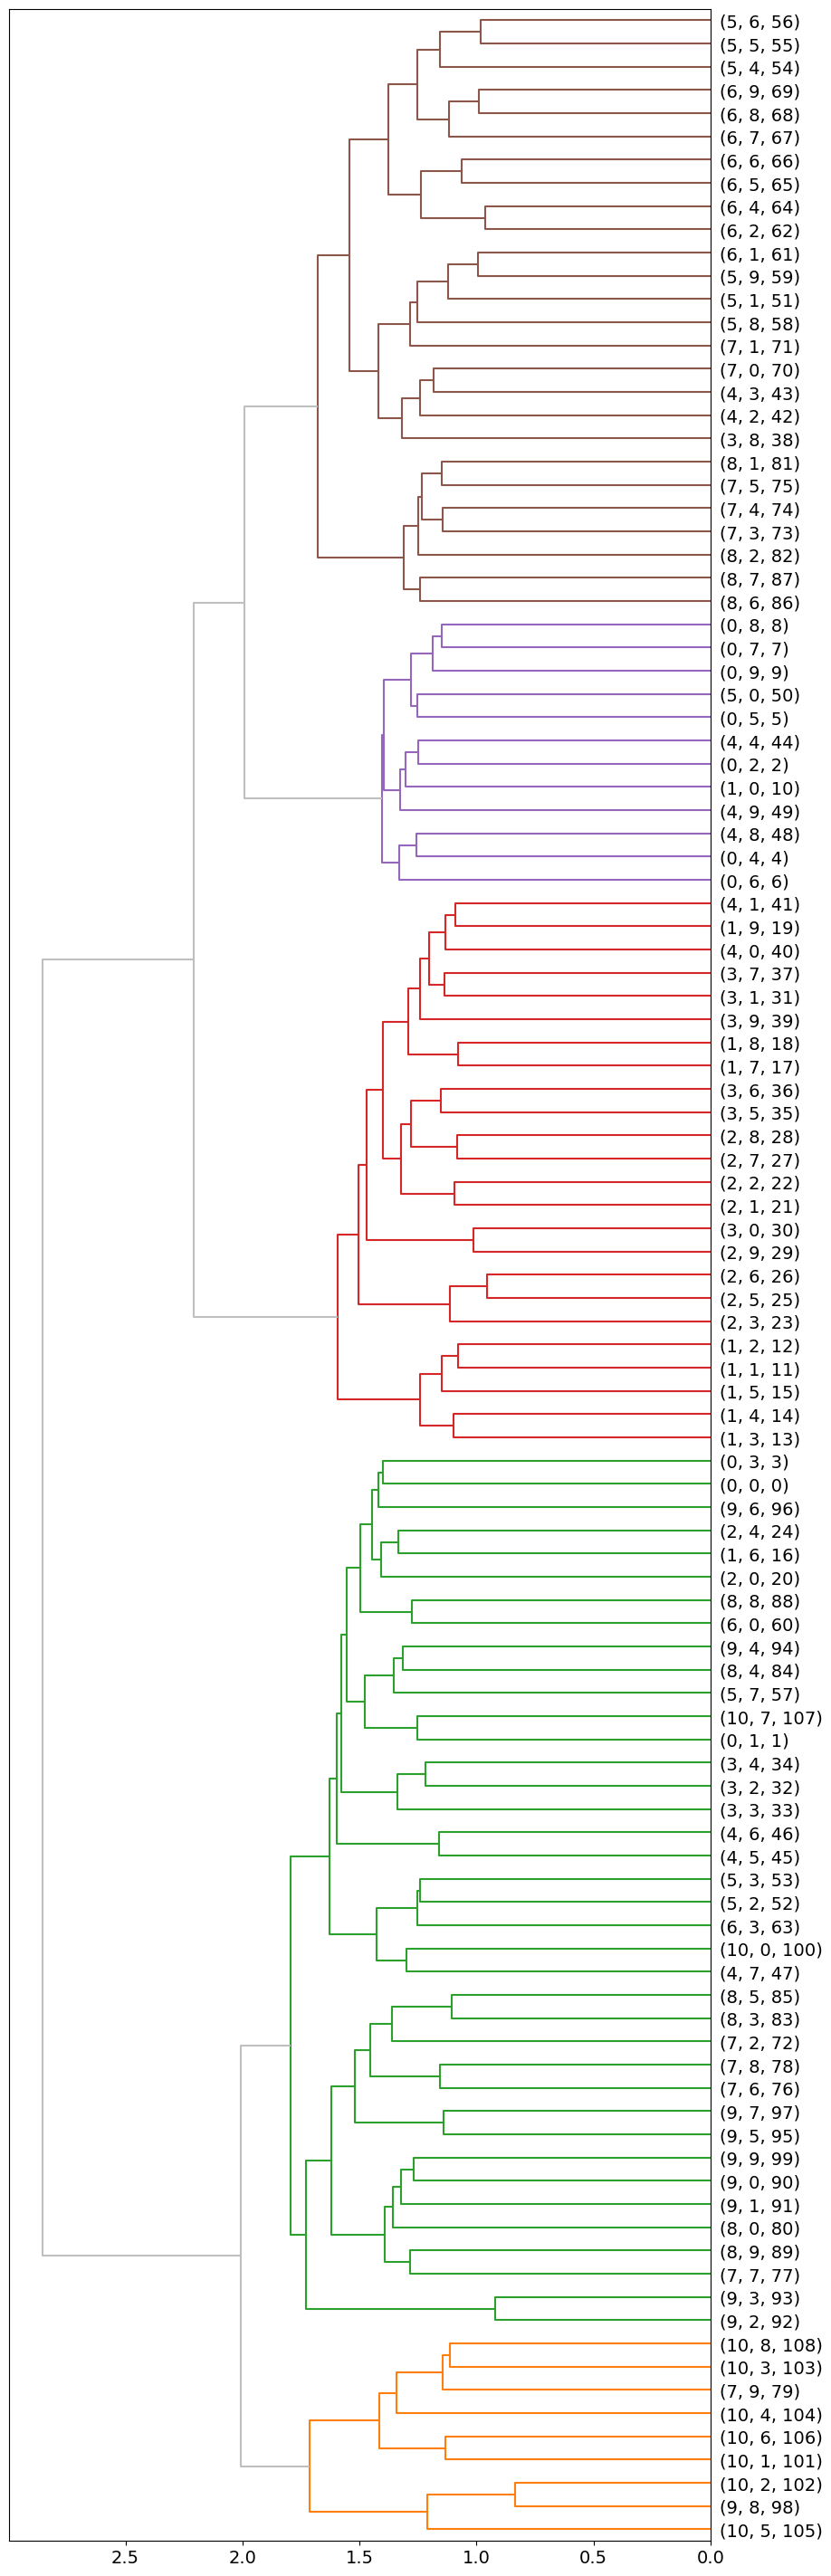

In [87]:
fig1.plot()

In [88]:
n_clusters = 5

In [89]:
cluster = AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=linkage)
DOC['label'] = cluster.fit_predict(X2) + 1

In [90]:
DOC.reset_index().set_index(['g1','g2']).label.unstack(fill_value=0).style.background_gradient(axis=None, cmap='Paired')

g2,0,1,2,3,4,5,6,7,8,9
g1,,,,,,,,,,
0,1,1,5,1,5,5,5,5,5,5
1,5,3,3,3,3,3,1,3,3,3
2,1,3,3,3,1,3,3,3,3,3
3,3,3,1,1,1,3,3,3,4,3
4,3,3,4,4,5,1,1,1,5,5
5,5,4,1,1,4,4,4,1,4,4
6,1,4,4,1,4,4,4,4,4,4
7,4,4,1,4,4,4,1,1,1,2
8,1,4,4,1,1,1,4,4,1,1


In [91]:
DOC.groupby(['g1','label']).count().doc_str.unstack(fill_value=0).T.style.background_gradient(cmap='Blues', axis=None)

g1,0,1,2,3,4,5,6,7,8,9,10
label,,,,,,,,,,,
1,3,1,2,3,3,3,2,4,6,9,2
2,0,0,0,0,0,0,0,1,0,1,7
3,0,8,8,6,2,0,0,0,0,0,0
4,0,0,0,1,2,6,8,5,4,0,0
5,7,1,0,0,3,1,0,0,0,0,0


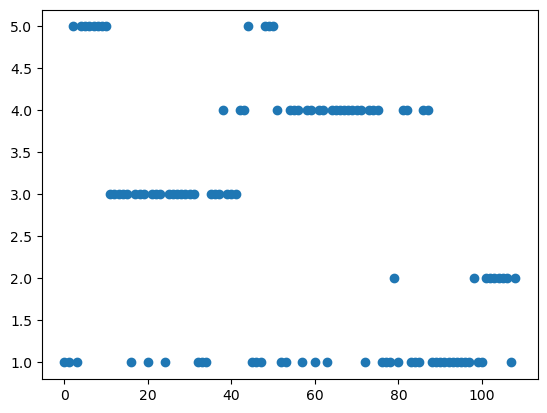

In [92]:
DOC.reset_index().label.plot(style='o');